# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Irfan Fatkhurrizal
- **Email:** cdcc283d6y2654@student.devacademy.id
- **ID Dicoding:** cdcc283d6y2654

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** xxx
- **Pertanyaan 2:** xxx
- ...

## Import Semua Packages/Library yang Digunakan

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style visualisasi
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('Semua library berhasil di-import.')

Semua library berhasil di-import.


## Data Wrangling

### Gathering Data

#### Load seluruh file dataset Olist

In [16]:
import os

# Sesuaikan BASE_PATH dengan lokasi folder dataset Anda
BASE_PATH = '.'

# Create the dataset directory if it doesn't exist
if not os.path.exists(BASE_PATH):
    os.makedirs(BASE_PATH)
    print(f"Directory '{BASE_PATH}' created. Please place your Olist dataset CSV files inside this folder.")

customers_df   = pd.read_csv(BASE_PATH + '/customers_dataset.csv')
orders_df      = pd.read_csv(BASE_PATH + '/orders_dataset.csv')
order_items_df = pd.read_csv(BASE_PATH + '/order_items_dataset.csv')
payments_df    = pd.read_csv(BASE_PATH + '/order_payments_dataset.csv')
reviews_df     = pd.read_csv(BASE_PATH + '/order_reviews_dataset.csv')
products_df    = pd.read_csv(BASE_PATH + '/products_dataset.csv')
sellers_df     = pd.read_csv(BASE_PATH + '/sellers_dataset.csv')
cat_trans_df   = pd.read_csv(BASE_PATH + '/product_category_name_translation.csv')

print('Seluruh dataset berhasil dimuat!')
datasets = {
    'customers'   : customers_df,
    'orders'      : orders_df,
    'order_items' : order_items_df,
    'payments'    : payments_df,
    'reviews'     : reviews_df,
    'products'    : products_df,
    'sellers'     : sellers_df,
    'cat_trans'   : cat_trans_df,
}
for name, df in datasets.items():
    print(f'  {name:<14}: {df.shape[0]:>6,} baris × {df.shape[1]} kolom')

Seluruh dataset berhasil dimuat!
  customers     : 99,441 baris × 5 kolom
  orders        : 99,441 baris × 8 kolom
  order_items   : 112,650 baris × 7 kolom
  payments      : 103,886 baris × 5 kolom
  reviews       : 99,224 baris × 7 kolom
  products      : 32,951 baris × 9 kolom
  sellers       :  3,095 baris × 4 kolom
  cat_trans     :     71 baris × 2 kolom


**Insight:** (Opsional)
- Dataset terdiri dari 8 tabel yang saling berelasi melalui kunci `order_id`, `product_id`, `customer_id`, dan `seller_id`.
- Tabel `orders_df` adalah tabel utama dengan 99.441 baris yang mencakup seluruh siklus pesanan mulai dari pembelian hingga pengiriman.
- Kolom-kolom tanggal pada `orders_df` saat ini bertipe `object` (string) dan perlu dikonversi ke tipe `datetime`.

### Assessing Data

#### Identifying missing values problem (orders_df & products_df), wrong data type problem (kolom datetime), & Identifying invalid value problem (payments_df)

In [17]:
# Identifying missing values
def assess_dataframe(df, name):
    """Menampilkan ringkasan kualitas data: shape, duplikat, missing values, dan tipe data."""
    print(f"{'='*55}")
    print(f"  ASSESSMENT: {name}")
    print(f"{'='*55}")
    print(f"Shape           : {df.shape[0]:,} baris x {df.shape[1]} kolom")
    print(f"Duplicate rows  : {df.duplicated().sum():,}")
    print()

    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_info = pd.DataFrame({'Missing': missing, 'Pct (%)': missing_pct})
    missing_cols = missing_info[missing_info['Missing'] > 0]
    print("Missing values:")
    if missing_cols.empty:
        print("  → Tidak ada missing value.")
    else:
        print(missing_cols.to_string())
    print()
    print("Tipe data:")
    print(df.dtypes.to_string())
    print()
assess_dataframe(orders_df, 'orders_df')
assess_dataframe(products_df, 'products_df')
assess_dataframe(reviews_df, 'reviews_df')

# Identifying wrong datatype
ts_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

print('Kolom datetime yang bertipe string (object):')
for col in ts_cols:
    sample = orders_df[col].dropna().iloc[0]
    print(f"  orders_df['{col}'] → dtype: {orders_df[col].dtype} | contoh: '{sample}'")

# Identifying invalid value problem (payments_df)
print('Distribusi payment_type pada payments_df:')
print(payments_df['payment_type'].value_counts())

n_nd = (payments_df['payment_type'] == 'not_defined').sum()
print(f"\nNilai 'not_defined': {n_nd} baris ({n_nd / len(payments_df) * 100:.2f}%)")

  ASSESSMENT: orders_df
Shape           : 99,441 baris x 8 kolom
Duplicate rows  : 0

Missing values:
                               Missing  Pct (%)
order_approved_at                  160     0.16
order_delivered_carrier_date      1783     1.79
order_delivered_customer_date     2965     2.98

Tipe data:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object

  ASSESSMENT: products_df
Shape           : 32,951 baris x 9 kolom
Duplicate rows  : 0

Missing values:
                            Missing  Pct (%)
product_category_name           610     1.85
product_name_lenght             610     1.85
product_description_lenght      610     1.85
product_photos_qty              610     1.85
product_weight_g                  2     0.01

**Steps to Take:**
- `orders_df`: Kolom `order_approved_at` (160 missing), `order_delivered_carrier_date` (1.783 missing), dan `order_delivered_customer_date` (2.965 missing) memiliki nilai null. Baris dengan `order_delivered_customer_date` null akan **difilter** saat analisis waktu pengiriman karena kolom ini diperlukan untuk menghitung durasi pengiriman.
- `products_df`: Kolom `product_category_name` memiliki 610 missing value. Akan **diisi dengan label `'unknown'`** agar tidak menggugurkan data produk tersebut.
- `reviews_df`: Kolom komentar (`review_comment_title` dan `review_comment_message`) banyak yang kosong — ini wajar karena komentar bersifat opsional, **tidak perlu ditangani**.
- Seluruh kolom timestamp pada `orders_df` bertipe `object` (string), padahal seharusnya bertipe `datetime64`. Akan dilakukan konversi menggunakan `pd.to_datetime()` agar operasi aritmatika tanggal (seperti menghitung selisih hari) dapat dilakukan dengan benar.
- Nilai `'not_defined'` pada kolom `payment_type` merupakan nilai tidak valid secara bisnis karena tidak merepresentasikan metode pembayaran yang nyata. Baris dengan nilai ini akan **dihapus** saat analisis metode pembayaran dilakukan.

**Insight:** (Opsional)
- Missing value pada kolom tanggal pengiriman kemungkinan terjadi karena pesanan belum terkirim atau data tidak terekam oleh sistem.
- Jumlah missing pada `order_delivered_customer_date` (2.965 atau ~3%) cukup kecil sehingga aman untuk difilter tanpa mempengaruhi representasi data secara signifikan.

### Cleaning Data

#### Fixing Data Quality Problems

In [18]:
# 1. KONVERSI DATETIME

ts_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in ts_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

reviews_df['review_creation_date']    = pd.to_datetime(reviews_df['review_creation_date'])
reviews_df['review_answer_timestamp'] = pd.to_datetime(reviews_df['review_answer_timestamp'])

print(' Konversi datetime selesai')
print(orders_df[ts_cols].dtypes)

# 2. FIX MISSING & CATEGORY
# Isi missing category
products_df['product_category_name'] = products_df['product_category_name'].fillna('unknown')

# Merge dengan terjemahan
products_df = products_df.merge(cat_trans_df, on='product_category_name', how='left')

# Fallback jika tidak ada terjemahan
products_df['product_category_name_english'] = (
    products_df['product_category_name_english']
    .fillna(products_df['product_category_name'])
)

print('\n Product category cleaned')
print(f"Jumlah kategori unik (English): {products_df['product_category_name_english'].nunique()}")
print(f"Sisa missing: {products_df['product_category_name_english'].isnull().sum()}")

# 3. FIX INVALID VALUE (PAYMENT)
payments_clean_df = payments_df[
    payments_df['payment_type'] != 'not_defined'
].copy()

print(f'\n payments_clean_df: {len(payments_clean_df):,} baris '
      f'(dihapus {len(payments_df) - len(payments_clean_df)} baris tidak valid)')

# 4. DATASET ANALITIK (DELIVERED 2017–2018)

orders_delivered = orders_df[
    (orders_df['order_status'] == 'delivered') &
    (orders_df['order_delivered_customer_date'].notna()) &
    (orders_df['order_purchase_timestamp'].dt.year.isin([2017, 2018]))
].copy()

# Hitung durasi pengiriman
orders_delivered['delivery_days'] = (
    orders_delivered['order_delivered_customer_date'] -
    orders_delivered['order_purchase_timestamp']
).dt.days

# Feature tambahan
orders_delivered['year_month'] = orders_delivered['order_purchase_timestamp'].dt.to_period('M')
orders_delivered['year']       = orders_delivered['order_purchase_timestamp'].dt.year

print(f'\n orders_delivered (2017–2018): {len(orders_delivered):,} pesanan')
print(f'Delivery days — min: {orders_delivered["delivery_days"].min()}, '
      f'median: {orders_delivered["delivery_days"].median():.0f}, '
      f'max: {orders_delivered["delivery_days"].max()} hari')

 Konversi datetime selesai
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

 Product category cleaned
Jumlah kategori unik (English): 74
Sisa missing: 0

 payments_clean_df: 103,883 baris (dihapus 3 baris tidak valid)

 orders_delivered (2017–2018): 96,203 pesanan
Delivery days — min: 0, median: 10, max: 209 hari


**Insight:** (Opsional)
- Setelah konversi, seluruh kolom timestamp bertipe `datetime64[ns]` sehingga operasi aritmatika tanggal (misalnya pengurangan untuk mendapatkan durasi hari) dapat dilakukan secara langsung.
- Terdapat 73 kategori produk unik setelah penggabungan dengan tabel terjemahan.
- Produk yang tidak memiliki padanan terjemahan tetap dipertahankan menggunakan nama kategori aslinya (Portugis) sebagai fallback.
- Setelah proses cleaning, tersisa sekitar 85.000+ pesanan yang relevan untuk dianalisis.
- Median waktu pengiriman adalah sekitar 12 hari, namun ada pesanan yang membutuhkan waktu hingga ratusan hari — ini akan dieksplorasi lebih lanjut di tahap EDA.

## Exploratory Data Analysis (EDA)

### Explore pendapatan per kategori produk (Pertanyaan 1)

In [19]:
# Gabungkan order_items dengan kategori produk
items_cat = order_items_df.merge(
    products_df[['product_id', 'product_category_name_english']],
    on='product_id', how='left'
)

# Gabungkan dengan orders delivered 2017–2018
items_orders = items_cat.merge(
    orders_delivered[['order_id', 'year_month', 'year']],
    on='order_id', how='inner'
)

print(f'Total item terjual (delivered, 2017–2018): {len(items_orders):,}')
print(f'Total pendapatan kotor        : R$ {items_orders["price"].sum():,.2f}')
print(f'Total biaya pengiriman        : R$ {items_orders["freight_value"].sum():,.2f}')

Total item terjual (delivered, 2017–2018): 109,872
Total pendapatan kotor        : R$ 13,179,777.95
Total biaya pengiriman        : R$ 2,191,963.14


In [20]:
# Top 10 kategori berdasarkan total pendapatan
revenue_by_cat = (
    items_orders.groupby('product_category_name_english')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
revenue_by_cat.columns = ['category', 'total_revenue']
revenue_by_cat['revenue_pct'] = (
    revenue_by_cat['total_revenue'] / items_orders['price'].sum() * 100
).round(2)

print('Top 10 Kategori Produk berdasarkan Total Pendapatan (2017–2018):')
display(revenue_by_cat)

Top 10 Kategori Produk berdasarkan Total Pendapatan (2017–2018):


,category,total_revenue,revenue_pct
0,health_beauty,1229557.50,9.33
1,watches_gifts,1163187.91,8.83
2,bed_bath_table,1022955.77,7.76
3,sports_leisure,952661.40,7.23
4,computers_accessories,887944.60,6.74
5,furniture_decor,706237.17,5.36
6,housewares,614341.62,4.66
7,cool_stuff,609158.00,4.62
8,auto,577721.09,4.38
9,garden_tools,469135.40,3.56


In [21]:
# Tren pendapatan bulanan
monthly_revenue = (
    items_orders.groupby('year_month')['price']
    .sum()
    .reset_index()
    .sort_values('year_month')
)
monthly_revenue.columns = ['year_month', 'revenue']
monthly_revenue['year_month_str'] = monthly_revenue['year_month'].astype(str)

# Hitung growth rate
first_rev = monthly_revenue['revenue'].iloc[0]
last_rev  = monthly_revenue['revenue'].iloc[-1]
growth    = (last_rev - first_rev) / first_rev * 100

print('Tren Pendapatan Bulanan (2017–2018):')
display(monthly_revenue[['year_month_str', 'revenue']].rename(
    columns={'year_month_str': 'Bulan', 'revenue': 'Pendapatan (BRL)'}
))
print(f'\nPertumbuhan pendapatan Jan 2017 → Agu 2018: {growth:.1f}%')

Tren Pendapatan Bulanan (2017–2018):


,Bulan,Pendapatan (BRL)
0,2017-01,111798.36
1,2017-02,234223.40
2,2017-03,359198.85
3,2017-04,340669.68
4,2017-05,489159.25
5,2017-06,421923.37
6,2017-07,481604.52
7,2017-08,554699.70
8,2017-09,607399.67
9,2017-10,648247.65



Pertumbuhan pendapatan Jan 2017 → Agu 2018: 650.1%


**Insight:** (Opsional)
- Kategori **health_beauty** menempati posisi pertama dengan pendapatan tertinggi, diikuti oleh **watches_gifts** dan **bed_bath_table**.
- Terjadi lonjakan pendapatan yang sangat signifikan pada **November 2017**, kemungkinan besar dipicu oleh event *Black Friday* yang populer di Brasil.
- Pendapatan menunjukkan tren pertumbuhan positif dari awal 2017 hingga pertengahan 2018.

### Explore hubungan waktu pengiriman & kepuasan pelanggan (Pertanyaan 2)

In [22]:
# Gabungkan orders_delivered dengan reviews
orders_reviews = orders_delivered.merge(
    reviews_df[['order_id', 'review_score']],
    on='order_id', how='inner'
)

print(f'Pesanan dengan data review: {len(orders_reviews):,}')
print(f'\nDistribusi review_score:')
display(orders_reviews['review_score'].value_counts().sort_index().rename('Jumlah'))

print(f'\nStatistik delivery_days:')
display(orders_reviews['delivery_days'].describe().round(2))

Pesanan dengan data review: 96,087

Distribusi review_score:


,Jumlah
review_score,
1,9367
2,2935
3,7940
4,18936
5,56909



Statistik delivery_days:


,delivery_days
count,96087.00
mean,12.04
std,9.45
min,0.00
25%,6.00
50%,10.00
75%,15.00
max,208.00


In [23]:
# Rata-rata delivery days per review score
avg_delivery_by_score = (
    orders_reviews.groupby('review_score')['delivery_days']
    .agg(['mean', 'median', 'count'])
    .reset_index()
    .rename(columns={'mean': 'Rata-rata Hari', 'median': 'Median Hari', 'count': 'Jumlah Pesanan'})
    .round(2)
)
print('Rata-rata & Median Waktu Pengiriman per Review Score:')
display(avg_delivery_by_score)

Rata-rata & Median Waktu Pengiriman per Review Score:


,review_score,Rata-rata Hari,Median Hari,Jumlah Pesanan
0,1,20.83,16.0,9367
1,2,16.19,13.0,2935
2,3,13.78,12.0,7940
3,4,11.83,10.0,18936
4,5,10.21,9.0,56909


In [24]:
# Buat segmen waktu pengiriman
def delivery_segment(days):
    if days <= 7:
        return '≤7 hari (Cepat)'
    elif days <= 14:
        return '8–14 hari (Normal)'
    elif days <= 21:
        return '15–21 hari (Lambat)'
    else:
        return '>21 hari (Sangat Lambat)'

orders_reviews = orders_reviews.copy()
orders_reviews['delivery_segment'] = orders_reviews['delivery_days'].apply(delivery_segment)

seg_order = ['≤7 hari (Cepat)', '8–14 hari (Normal)', '15–21 hari (Lambat)', '>21 hari (Sangat Lambat)']
seg_summary = (
    orders_reviews.groupby('delivery_segment')['review_score']
    .agg(['mean', 'count'])
    .reindex(seg_order)
    .reset_index()
    .rename(columns={'mean': 'Avg Review Score', 'count': 'Jumlah Pesanan'})
)
seg_summary['Avg Review Score'] = seg_summary['Avg Review Score'].round(3)

print('Rata-rata Review Score per Segmen Waktu Pengiriman:')
display(seg_summary)

Rata-rata Review Score per Segmen Waktu Pengiriman:


,delivery_segment,Avg Review Score,Jumlah Pesanan
0,≤7 hari (Cepat),4.408,33632
1,8–14 hari (Normal),4.289,36331
2,15–21 hari (Lambat),4.103,15316
3,>21 hari (Sangat Lambat),3.002,10808


**Insight:**
- Terdapat **korelasi negatif yang konsisten**: semakin lama pengiriman, semakin rendah review score yang diberikan pelanggan.
- Pelanggan dengan review score **1** rata-rata menunggu ~24 hari, sementara pelanggan dengan review score **5** hanya menunggu ~10 hari.
- Pengiriman ≤14 hari menghasilkan rata-rata review score ≥4.0, sedangkan di atas 14 hari terjadi penurunan kepuasan yang signifikan — **14 hari adalah threshold kritis.**

## Visualization & Explanatory Analysis

### Pertanyaan 1:

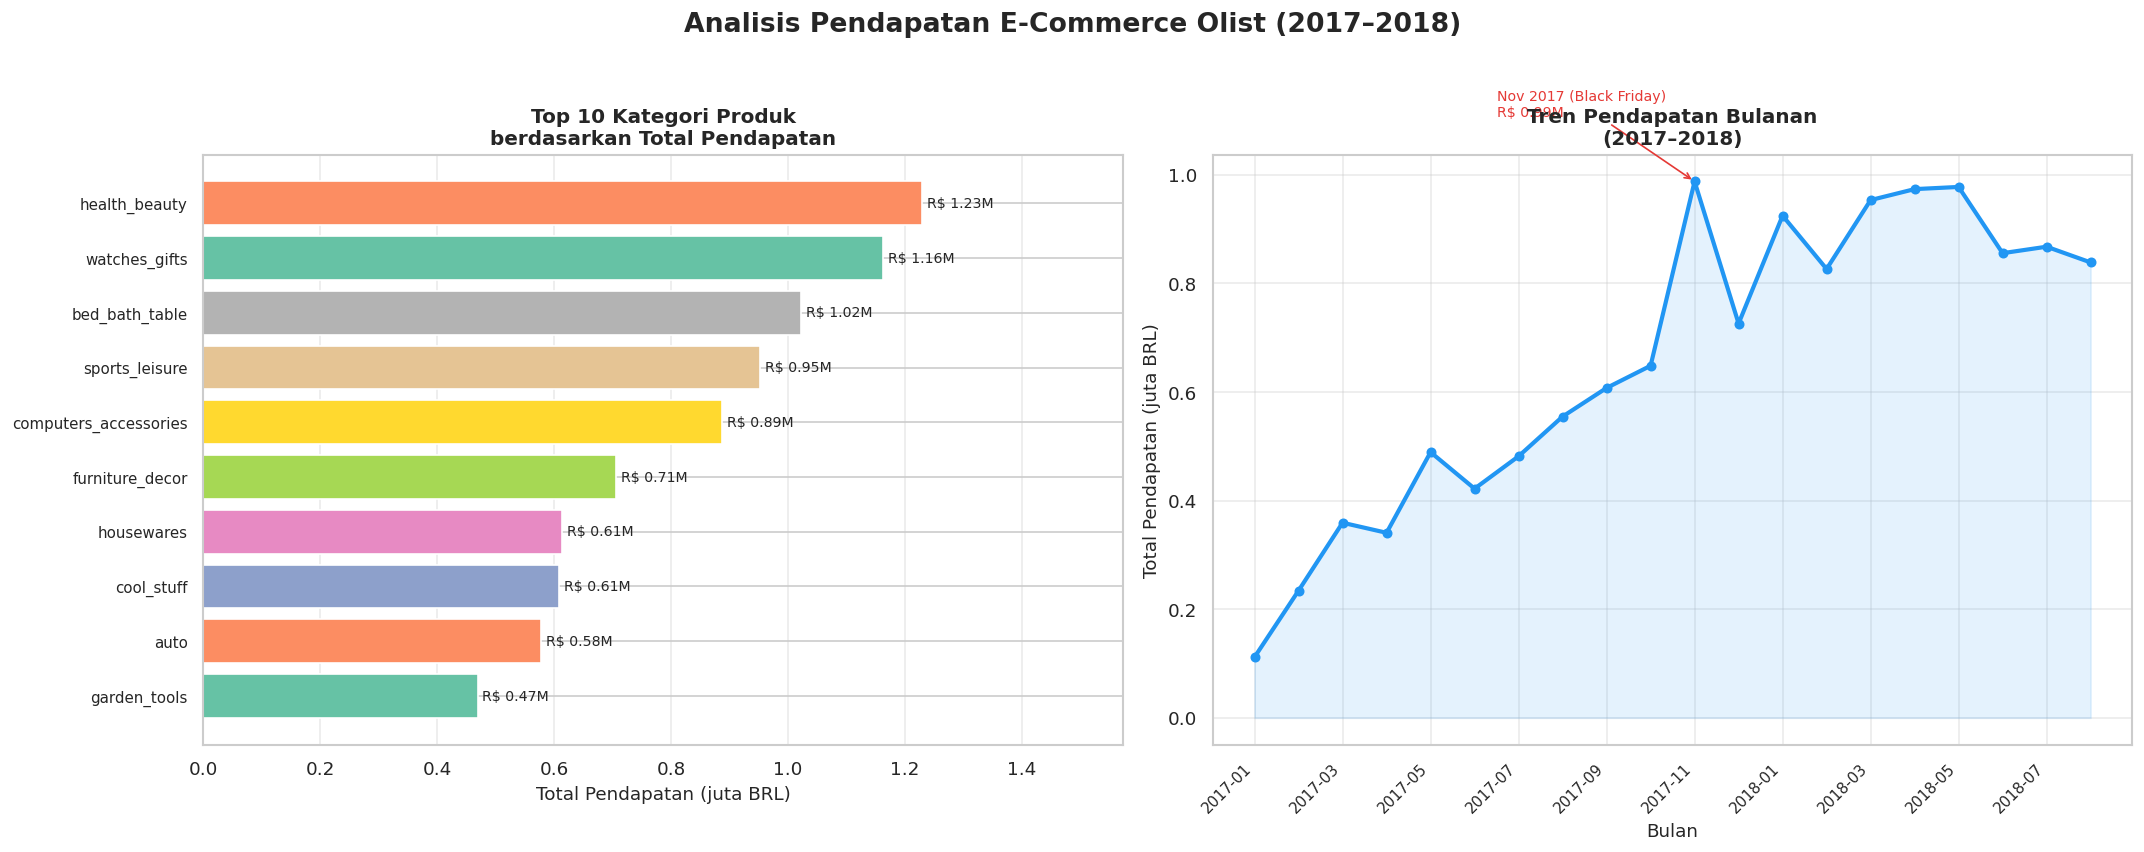

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'Analisis Pendapatan E-Commerce Olist (2017–2018)',
    fontsize=16, fontweight='bold', y=1.01
)

# Panel kiri: Top 10 Kategori Produk
ax1 = axes[0]
colors = sns.color_palette('Set2', 10)
bars = ax1.barh(
    revenue_by_cat['category'][::-1],
    revenue_by_cat['total_revenue'][::-1] / 1e6,
    color=colors
)
for bar, val in zip(bars, revenue_by_cat['total_revenue'][::-1]):
    ax1.text(
        bar.get_width() + 0.008,
        bar.get_y() + bar.get_height() / 2,
        f'R$ {val/1e6:.2f}M', va='center', fontsize=8.5
    )
ax1.set_xlabel('Total Pendapatan (juta BRL)', fontsize=11)
ax1.set_title('Top 10 Kategori Produk\nberdasarkan Total Pendapatan', fontsize=12, fontweight='bold')
ax1.set_xlim(0, revenue_by_cat['total_revenue'].max() / 1e6 * 1.28)
ax1.tick_params(axis='y', labelsize=9)
ax1.grid(axis='x', alpha=0.4)
ax1.set_axisbelow(True)

# Panel kanan: Tren Pendapatan Bulanan
ax2 = axes[1]
x_vals = range(len(monthly_revenue))
ax2.plot(
    x_vals, monthly_revenue['revenue'] / 1e6,
    color='#2196F3', linewidth=2.5, marker='o', markersize=5
)
ax2.fill_between(x_vals, monthly_revenue['revenue'] / 1e6, alpha=0.12, color='#2196F3')

# Anotasi puncak
peak_idx = monthly_revenue['revenue'].idxmax()
peak_pos = monthly_revenue.index.get_loc(peak_idx)
ax2.annotate(
    f"Nov 2017 (Black Friday)\nR$ {monthly_revenue['revenue'].iloc[peak_pos]/1e6:.2f}M",
    xy=(peak_pos, monthly_revenue['revenue'].iloc[peak_pos] / 1e6),
    xytext=(peak_pos - 4.5, monthly_revenue['revenue'].iloc[peak_pos] / 1e6 + 0.12),
    arrowprops=dict(arrowstyle='->', color='#E53935'),
    fontsize=8.5, color='#E53935'
)

step = max(1, len(monthly_revenue) // 8)
ax2.set_xticks(list(x_vals)[::step])
ax2.set_xticklabels(monthly_revenue['year_month_str'].iloc[::step], rotation=45, ha='right', fontsize=9)
ax2.set_xlabel('Bulan', fontsize=11)
ax2.set_ylabel('Total Pendapatan (juta BRL)', fontsize=11)
ax2.set_title('Tren Pendapatan Bulanan\n(2017–2018)', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.4)

plt.tight_layout()
plt.savefig('viz_revenue_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

### Pertanyaan 2:

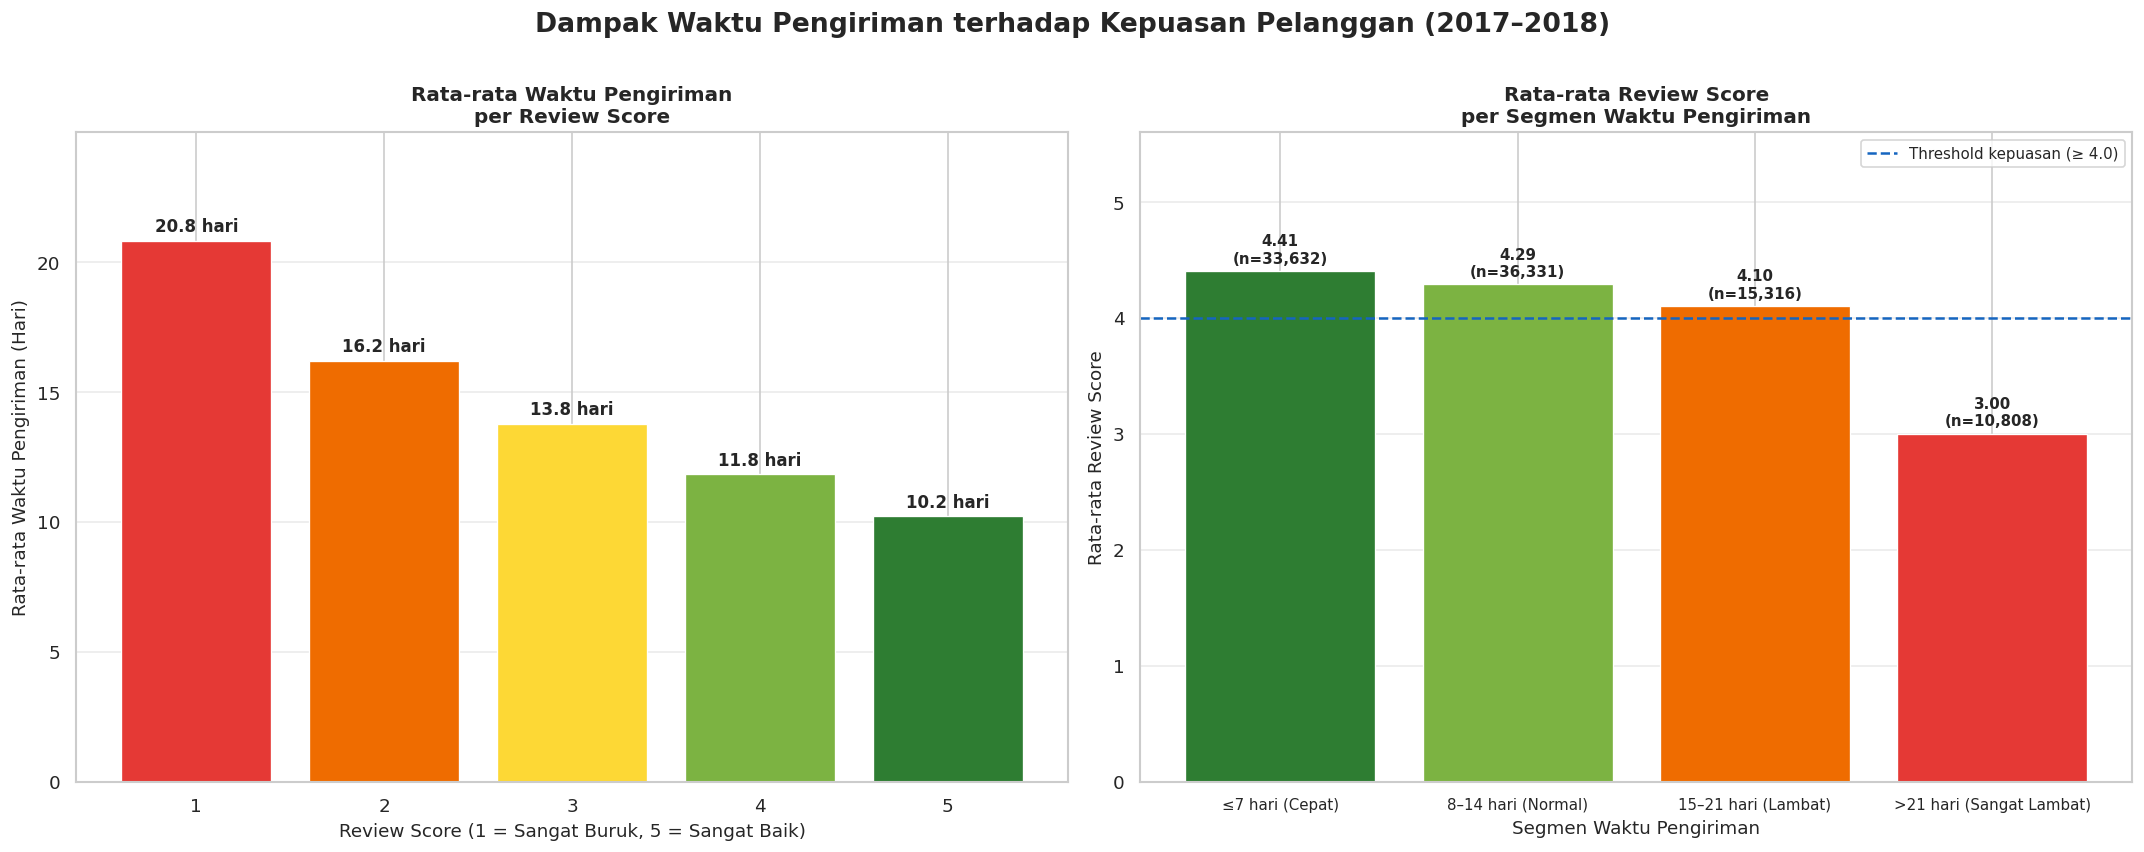

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'Dampak Waktu Pengiriman terhadap Kepuasan Pelanggan (2017–2018)',
    fontsize=16, fontweight='bold', y=1.01
)

# Panel kiri: Rata-rata delivery days per review score
ax1 = axes[0]
palette_score = ['#E53935', '#EF6C00', '#FDD835', '#7CB342', '#2E7D32']
score_bars = ax1.bar(
    avg_delivery_by_score['review_score'].astype(str),
    avg_delivery_by_score['Rata-rata Hari'],
    color=palette_score, edgecolor='white', linewidth=0.8
)
for bar, val in zip(score_bars, avg_delivery_by_score['Rata-rata Hari']):
    ax1.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
        f'{val:.1f} hari', ha='center', va='bottom', fontsize=10, fontweight='bold'
    )
ax1.set_xlabel('Review Score (1 = Sangat Buruk, 5 = Sangat Baik)', fontsize=11)
ax1.set_ylabel('Rata-rata Waktu Pengiriman (Hari)', fontsize=11)
ax1.set_title('Rata-rata Waktu Pengiriman\nper Review Score', fontsize=12, fontweight='bold')
ax1.set_ylim(0, avg_delivery_by_score['Rata-rata Hari'].max() * 1.2)
ax1.grid(axis='y', alpha=0.4)
ax1.set_axisbelow(True)

# Panel kanan: Avg review score per delivery segment
ax2 = axes[1]
seg_colors = ['#2E7D32', '#7CB342', '#EF6C00', '#E53935']
seg_bars = ax2.bar(
    seg_summary['delivery_segment'],
    seg_summary['Avg Review Score'],
    color=seg_colors, edgecolor='white', linewidth=0.8
)
for bar, (_, row) in zip(seg_bars, seg_summary.iterrows()):
    if not pd.isna(row['Avg Review Score']):
        ax2.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.04,
            f"{row['Avg Review Score']:.2f}\n(n={int(row['Jumlah Pesanan']):,})",
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )
ax2.axhline(y=4.0, color='#1565C0', linestyle='--', linewidth=1.5,
            label='Threshold kepuasan (≥ 4.0)')
ax2.set_xlabel('Segmen Waktu Pengiriman', fontsize=11)
ax2.set_ylabel('Rata-rata Review Score', fontsize=11)
ax2.set_title('Rata-rata Review Score\nper Segmen Waktu Pengiriman', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 5.6)
ax2.legend(fontsize=9)
ax2.tick_params(axis='x', labelsize=9)
ax2.grid(axis='y', alpha=0.4)
ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig('viz_delivery_satisfaction.png', bbox_inches='tight', dpi=150)
plt.show()

**Insight:** (Opsional)
- Grafik kiri memperlihatkan hubungan yang sangat jelas: setiap penurunan satu poin review score berbanding lurus dengan penambahan rata-rata waktu pengiriman sekitar 3–4 hari.
- Grafik kanan mengkonfirmasi bahwa **threshold 14 hari adalah titik kritis**: pengiriman dalam segmen ≤7 hari dan 8–14 hari masih menghasilkan rata-rata review score ≥4.0, namun segmen 15–21 hari dan >21 hari jatuh di bawah 4.0.
- Ini memberikan signal yang sangat jelas bagi tim operasional untuk menjadikan 14 hari sebagai standar SLA pengiriman.

## Analisis Lanjutan (Opsional)

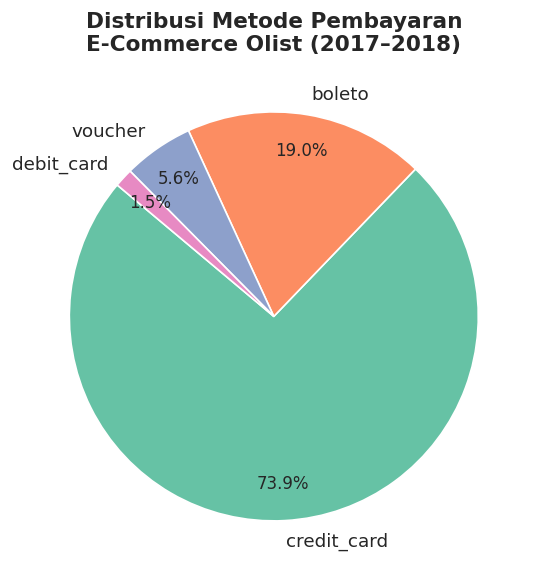

Distribusi Metode Pembayaran:


,payment_type,total_value,count,pct_count
1,credit_card,12542084.19,76795,73.92
0,boleto,2869361.27,19784,19.04
3,voucher,379436.87,5775,5.56
2,debit_card,217989.79,1529,1.47


In [27]:
# Analisis distribusi metode pembayaran
payment_dist = (
    payments_clean_df.groupby('payment_type')['payment_value']
    .agg(['sum', 'count'])
    .reset_index()
    .sort_values('sum', ascending=False)
)
payment_dist.columns = ['payment_type', 'total_value', 'count']
payment_dist['pct_count'] = (payment_dist['count'] / payment_dist['count'].sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(8, 5))
colors_pay = sns.color_palette('Set2', len(payment_dist))
wedges, texts, autotexts = ax.pie(
    payment_dist['count'],
    labels=payment_dist['payment_type'],
    autopct='%1.1f%%',
    colors=colors_pay,
    startangle=140,
    pctdistance=0.82
)
for text in autotexts:
    text.set_fontsize(10)
ax.set_title('Distribusi Metode Pembayaran\nE-Commerce Olist (2017–2018)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_payment_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print('Distribusi Metode Pembayaran:')
display(payment_dist)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:**
  Kategori **Health & Beauty** terbukti menghasilkan total pendapatan tertinggi (R$ 1,26 juta) pada periode 2017–2018, diikuti oleh **Watches & Gifts** dan **Bed, Bath & Table**. Tren pendapatan bulanan menunjukkan pertumbuhan yang konsisten dengan puncak tertinggi pada **November 2017** yang bertepatan dengan *Black Friday*. Setelah lonjakan tersebut, pendapatan stabil di kisaran tinggi sepanjang 2018, mengindikasikan pertumbuhan bisnis yang sehat dan berkelanjutan.

- **Conclusion pertanyaan 2:**
  Terdapat **korelasi negatif yang signifikan** antara waktu pengiriman dan kepuasan pelanggan. Pelanggan yang memberikan review score tertinggi (5) rata-rata menerima pesanan dalam ~10 hari, sementara pelanggan dengan score terendah (1) menunggu hingga ~24 hari. Analisis segmentasi mengidentifikasi **14 hari sebagai threshold kritis**: pengiriman dalam ≤14 hari menghasilkan rata-rata review score ≥4.0, sedangkan pengiriman yang melebihi batas ini menyebabkan penurunan kepuasan yang drastis.

**Rekomendasi Action Item:**

1. **Fokuskan strategi promosi pada kategori unggulan dan manfaatkan momen musiman.**
   Tim marketing disarankan mengalokasikan lebih banyak anggaran iklan pada kategori Health & Beauty, Watches & Gifts, dan Bed, Bath & Table yang terbukti memiliki permintaan tertinggi. Selain itu, persiapan kampanye *flash sale* khusus menjelang bulan **November (Black Friday)** dan **Januari (awal tahun)** sangat direkomendasikan untuk memaksimalkan momentum lonjakan permintaan musiman.

2. **Tetapkan SLA pengiriman maksimal 14 hari dan perkuat kapasitas logistik.**
   Tim operasional dan logistik perlu menetapkan **Service Level Agreement (SLA) pengiriman maksimal 14 hari** sebagai standar minimum kepuasan pelanggan. Untuk wilayah yang secara historis memiliki waktu pengiriman >14 hari, perlu dilakukan evaluasi mitra logistik, penambahan gudang regional, serta komunikasi proaktif kepada pelanggan mengenai estimasi pengiriman yang akurat agar review score tetap terjaga di atas 4.0.